# Kafka and Spark Streaming Exercise

**INFORMATION**: This exercise is easier on the cluster!

Kafka is an excellent tool for data engineering projects due to its distributed, fault-tolerant, and scalable architecture, which facilitates real-time data streaming and processing. It serves as a highly reliable messaging system that efficiently handles large volumes of data streams from diverse sources. Kafka's ability to decouple data producers from consumers and its support for parallel data processing make it ideal for building robust and scalable data pipelines. Additionally, Kafka's durability and fault-tolerance ensure that data is safely persisted and replicated across nodes, minimizing the risk of data loss and ensuring continuous data availability for downstream applications and analytics.

Spark Streaming enables the real-time processing of data streams with high throughput and low latency. It seamlessly integrates with Apache Spark's core APIs, allowing developers to leverage Spark's powerful data processing capabilities for streaming data. Spark Streaming supports a wide range of data sources, including Kafka, Flume, and HDFS, and can process data in near real-time, making it ideal for applications that require instant insights and timely responses.

Use Python, ```pyspark```, ```pandas```, ```confluent-kafka``` and/or ```kafka-python``` to send messages to a Kafka topic and analyse them with Spark Streaming:

# Kafka

## Import Necessary Libraries

In [2]:
import json
import time
from datetime import datetime, timedelta

import pandas as pd

from kafka import KafkaProducer, KafkaConsumer

from pyspark import SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType

In [3]:
KAFKA_BOOTSTRAP_SERVERS = "172.29.16.101:9092"
SPARK_MASTER = "spark://172.29.16.102:7077"
TOPIC_NAME = "beer_stream_group8"

print("Kafka broker:", KAFKA_BOOTSTRAP_SERVERS)
print("Spark master:", SPARK_MASTER)
print("Topic:", TOPIC_NAME)

Kafka broker: 172.29.16.101:9092
Spark master: spark://172.29.16.102:7077
Topic: beer_stream_group8


## Load a dataset to stream
Select a suitable dataset from previous exercises and split it into individual JSON messages.

In [4]:
df = pd.read_csv("cleaned_beer_data.csv")
df.columns = df.columns.str.strip()

df = df[[
    "Jahr",
    "Absatz_Bier_hl",
    "Braustaetten_Anzahl",
    "Verbrauch_pro_Kopf_l"
]].dropna()

df["Jahr"] = df["Jahr"].astype(int)
df["Braustaetten_Anzahl"] = df["Braustaetten_Anzahl"].astype(int)

messages = []

start_time = datetime.now().replace(microsecond=0)

for index, row in df.sort_values("Jahr").iterrows():
    message = {
        "event_time": (start_time + timedelta(seconds=len(messages) * 2)).isoformat(),
        "year": int(row["Jahr"]),
        "beer_sales_hl": float(row["Absatz_Bier_hl"]),
        "breweries": int(row["Braustaetten_Anzahl"]),
        "consumption_per_capita_l": float(row["Verbrauch_pro_Kopf_l"])
    }
    messages.append(message)

print("Number of prepared messages:", len(messages))
print("First message:")
print(json.dumps(messages[0], indent=2))

Number of prepared messages: 32
First message:
{
  "event_time": "2026-06-24T18:30:50",
  "year": 1994,
  "beer_sales_hl": 115660265.0,
  "breweries": 1299,
  "consumption_per_capita_l": 132.7
}


## Create a producer and stream the messages
You need to use a Kafka producer to connect to a broker and send the messages to a topic.

In [5]:
producer = KafkaProducer(
    bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
    value_serializer=lambda value: json.dumps(value).encode("utf-8"),
    key_serializer=lambda key: str(key).encode("utf-8")
)

for message in messages:
    producer.send(
        TOPIC_NAME,
        key=message["year"],
        value=message
    )
    print("Sent message for year:", message["year"])
    time.sleep(0.2)

producer.flush()
producer.close()

print("Finished sending messages to Kafka topic:", TOPIC_NAME)

Sent message for year: 1994
Sent message for year: 1995
Sent message for year: 1996
Sent message for year: 1997
Sent message for year: 1998
Sent message for year: 1999
Sent message for year: 2000
Sent message for year: 2001
Sent message for year: 2002
Sent message for year: 2003
Sent message for year: 2004
Sent message for year: 2005
Sent message for year: 2006
Sent message for year: 2007
Sent message for year: 2008
Sent message for year: 2009
Sent message for year: 2010
Sent message for year: 2011
Sent message for year: 2012
Sent message for year: 2013
Sent message for year: 2014
Sent message for year: 2015
Sent message for year: 2016
Sent message for year: 2017
Sent message for year: 2018
Sent message for year: 2019
Sent message for year: 2020
Sent message for year: 2021
Sent message for year: 2022
Sent message for year: 2023
Sent message for year: 2024
Sent message for year: 2025
Finished sending messages to Kafka topic: beer_stream_group8


## Create a consumer and check if the messages can be read
A Kafka consumer can subscribe to one or more topics and process the messages. Display the messages from the previous step.

In [6]:
consumer = KafkaConsumer(
    TOPIC_NAME,
    bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
    auto_offset_reset="earliest",
    enable_auto_commit=True,
    group_id="beer_stream_check_group8",
    value_deserializer=lambda value: json.loads(value.decode("utf-8")),
    consumer_timeout_ms=5000
)

received_messages = []

for message in consumer:
    received_messages.append(message.value)
    print(message.value)

    if len(received_messages) >= 5:
        break

consumer.close()

print("Number of displayed messages:", len(received_messages))

{'event_time': '2026-06-24T18:30:50', 'year': 1994, 'beer_sales_hl': 115660265.0, 'breweries': 1299, 'consumption_per_capita_l': 132.7}
{'event_time': '2026-06-24T18:30:52', 'year': 1995, 'beer_sales_hl': 115252060.0, 'breweries': 1282, 'consumption_per_capita_l': 131.1}
{'event_time': '2026-06-24T18:30:54', 'year': 1996, 'beer_sales_hl': 112806908.0, 'breweries': 1276, 'consumption_per_capita_l': 127.3}
{'event_time': '2026-06-24T18:30:56', 'year': 1997, 'beer_sales_hl': 112669814.0, 'breweries': 1273, 'consumption_per_capita_l': 126.7}
{'event_time': '2026-06-24T18:30:58', 'year': 1998, 'beer_sales_hl': 109384583.0, 'breweries': 1285, 'consumption_per_capita_l': 123.0}
Number of displayed messages: 5


# Kafka and Spark Streaming
Spark can act as a Kafka consumer. This gives you the benefits of the Spark framework to process the Kafka messages. 

The Kafka producer sent one JSON message per year from the cleaned beer dataset to the Kafka topic. Spark Structured Streaming then read the Kafka topic as a stream. The binary Kafka values were converted to strings and parsed as JSON using a defined schema. Afterwards, the data was grouped into 10-second event-time windows and simple aggregations were calculated, including the number of messages, average beer consumption per capita, and average number of breweries.

## Spark Context and Session

Initialize Spark Context and Spark Session

In [7]:
conf = SparkConf() \
    .setAppName("BDENG_Kafka_Spark_Streaming_Group8") \
    .setMaster(SPARK_MASTER) \
    .set("spark.jars.packages", "org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.6")

spark = SparkSession.builder.config(conf=conf).getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Spark Version:", spark.version)
print("Spark session connected.")

:: loading settings :: url = jar:file:/opt/spark-3.5.6/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/bdeng-g8/.ivy2/cache
The jars for the packages stored in: /home/bdeng-g8/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-d0bb4499-0a60-4b58-9b27-75a97680b4cb;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.5.6 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.5.6 in central
	found org.apache.kafka#kafka-clients;3.4.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.10.5 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
downloading https://repo1.maven.org/maven2/org/apache/spar

Spark Version: 3.5.6
Spark session connected.


## Create a Spark DataFrame from a Kafka stream

In [19]:
kafka_stream_df = spark.readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", KAFKA_BOOTSTRAP_SERVERS) \
    .option("subscribe", TOPIC_NAME) \
    .option("startingOffsets", "earliest") \
    .load()

print("Is streaming:", kafka_stream_df.isStreaming)

kafka_stream_df.printSchema()

Is streaming: True
root
 |-- key: binary (nullable = true)
 |-- value: binary (nullable = true)
 |-- topic: string (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- timestampType: integer (nullable = true)



## Convert the binary Kafka data to strings

In [18]:
kafka_string_df = kafka_stream_df.select(
    F.col("key").cast("string").alias("message_key"),
    F.col("value").cast("string").alias("message_value"),
    F.col("timestamp").alias("kafka_timestamp")
)

kafka_string_df.printSchema()

root
 |-- message_key: string (nullable = true)
 |-- message_value: string (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)



## Create a structured schema for the streamed data

Use objects like ```StructType```, ```StructField```, ```IntegerType```, ```BooleanType```, etc to create the schema. Afterwards apply the schema to the DataFrame.

In [10]:
message_schema = StructType([
    StructField("event_time", StringType(), True),
    StructField("year", IntegerType(), True),
    StructField("beer_sales_hl", DoubleType(), True),
    StructField("breweries", IntegerType(), True),
    StructField("consumption_per_capita_l", DoubleType(), True)
])

structured_stream_df = kafka_string_df \
    .select(
        F.from_json(F.col("message_value"), message_schema).alias("data"),
        F.col("kafka_timestamp")
    ) \
    .select(
        F.to_timestamp(F.col("data.event_time")).alias("event_time"),
        F.col("data.year").alias("year"),
        F.col("data.beer_sales_hl").alias("beer_sales_hl"),
        F.col("data.breweries").alias("breweries"),
        F.col("data.consumption_per_capita_l").alias("consumption_per_capita_l"),
        F.col("kafka_timestamp")
    )

print("JSON messages parsed into a structured Spark DataFrame.")
structured_stream_df.printSchema()

JSON messages parsed into a structured Spark DataFrame.
root
 |-- event_time: timestamp (nullable = true)
 |-- year: integer (nullable = true)
 |-- beer_sales_hl: double (nullable = true)
 |-- breweries: integer (nullable = true)
 |-- consumption_per_capita_l: double (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)



## Create a DataFrame grouped by a time window
E.g., the number of messages of the different types over the last minute.

In [17]:
windowed_df = structured_stream_df \
    .withWatermark("event_time", "1 minute") \
    .groupBy(
        F.window(F.col("event_time"), "10 seconds")
    ) \
    .agg(
        F.count("*").alias("number_of_messages"),
        F.round(F.avg("consumption_per_capita_l"), 2).alias("avg_consumption_per_capita_l"),
        F.round(F.avg("breweries"), 0).alias("avg_breweries")
    ) \
    .orderBy("window")

windowed_df.printSchema()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- number_of_messages: long (nullable = false)
 |-- avg_consumption_per_capita_l: double (nullable = true)
 |-- avg_breweries: double (nullable = true)



## Create a query stream of the DataFrame
Write the output of the DataFrame to a memory sink of your choice. Use the ```start()``` method to actually start the stream processing.

In [12]:
query = windowed_df.writeStream \
    .format("memory") \
    .queryName("beer_stream_results") \
    .outputMode("complete") \
    .option("checkpointLocation", "/tmp/beer_stream_checkpoint_group8") \
    .start()

print("Streaming query started.")

Streaming query started.


In [14]:
time.sleep(10)

spark.sql("""
    SELECT
        window.start AS window_start,
        window.end AS window_end,
        number_of_messages,
        avg_consumption_per_capita_l,
        avg_breweries
    FROM beer_stream_results
    ORDER BY window_start
""").show(truncate=False)

+-------------------+-------------------+------------------+----------------------------+-------------+
|window_start       |window_end         |number_of_messages|avg_consumption_per_capita_l|avg_breweries|
+-------------------+-------------------+------------------+----------------------------+-------------+
|2026-06-24 18:30:50|2026-06-24 18:31:00|5                 |128.16                      |1283.0       |
|2026-06-24 18:31:00|2026-06-24 18:31:10|5                 |118.84                      |1285.0       |
|2026-06-24 18:31:10|2026-06-24 18:31:20|5                 |109.96                      |1297.0       |
|2026-06-24 18:31:20|2026-06-24 18:31:30|5                 |102.2                       |1341.0       |
|2026-06-24 18:31:30|2026-06-24 18:31:40|5                 |96.12                       |1441.0       |
|2026-06-24 18:31:40|2026-06-24 18:31:50|5                 |86.52                       |1528.0       |
|2026-06-24 18:31:50|2026-06-24 18:32:00|2                 |79.3

## Export the processed data as a Pandas DataFrame and visualize it

In [30]:
result_df = spark.sql("""
    SELECT
        window.start AS window_start,
        window.end AS window_end,
        number_of_messages,
        avg_consumption_per_capita_l,
        avg_breweries
    FROM beer_stream_results
    ORDER BY window_start
""")

result_pdf = result_df.toPandas()

print("Processed streaming result:")
display(result_pdf)

result_pdf.to_csv("spark_streaming_results.csv", index=False)

Processed streaming result:


,window_start,window_end,number_of_messages,avg_consumption_per_capita_l,avg_breweries
0,2026-06-24 18:30:50,2026-06-24 18:31:00,5,128.16,1283.0
1,2026-06-24 18:31:00,2026-06-24 18:31:10,5,118.84,1285.0
2,2026-06-24 18:31:10,2026-06-24 18:31:20,5,109.96,1297.0
3,2026-06-24 18:31:20,2026-06-24 18:31:30,5,102.20,1341.0
4,2026-06-24 18:31:30,2026-06-24 18:31:40,5,96.12,1441.0
5,2026-06-24 18:31:40,2026-06-24 18:31:50,5,86.52,1528.0
6,2026-06-24 18:31:50,2026-06-24 18:32:00,2,79.30,1442.0


In [28]:
import matplotlib.pyplot as plt

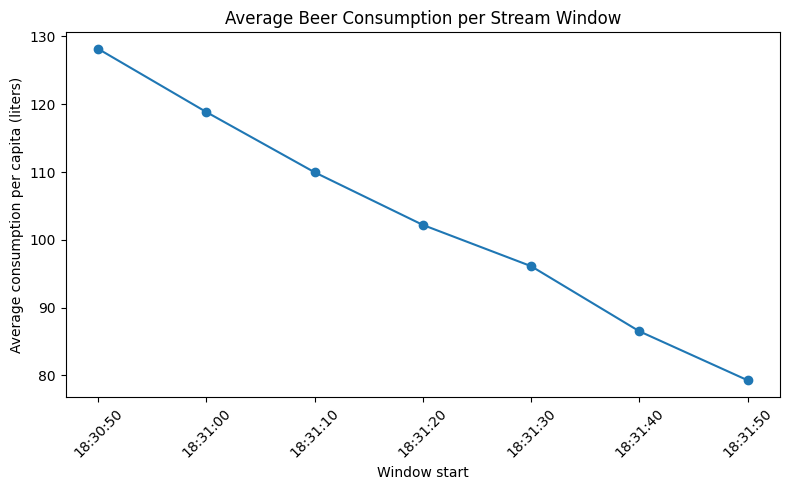

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(
    result_pdf["window_start"],
    result_pdf["avg_consumption_per_capita_l"],
    marker="o"
)
plt.title("Average Beer Consumption per Stream Window")
plt.xlabel("Window start")
plt.ylabel("Average consumption per capita (liters)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

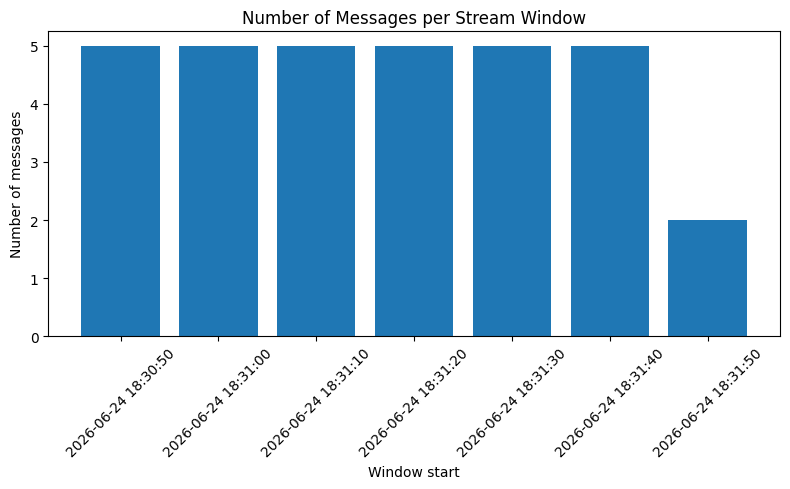

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(
    result_pdf["window_start"].astype(str),
    result_pdf["number_of_messages"]
)
plt.title("Number of Messages per Stream Window")
plt.xlabel("Window start")
plt.ylabel("Number of messages")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
query.stop()

The Kafka producer sent one JSON message per year from the cleaned beer dataset to the Kafka topic. Spark Structured Streaming then read the Kafka topic as a stream. The binary Kafka values were converted to strings and parsed as JSON using a defined schema. Afterwards, the data was grouped into 10-second event-time windows and simple aggregations were calculated, including the number of messages, average beer consumption per capita, and average number of breweries.